# De combien la Terre ment-elle dans les dix premières minutes ?

Quand un séisme se produit, l'USGS publie en moins de deux minutes une magnitude
calculée automatiquement. Des heures — parfois des mois — plus tard, un
sismologue la révise. L'écart entre les deux décide d'une évacuation, d'une
alerte tsunami, d'une mobilisation de secours.

Ce carnet lit **directement les tables Gold en Parquet depuis HDFS**, sans Spark
et sans recalcul : tout ce qui suit a été produit par les jobs de la couche
Gold, orchestrés par Airflow.

In [1]:
import sys
sys.path.insert(0, "/opt/app")

import pandas as pd
import matplotlib.pyplot as plt

from src.common.gold_reader import available_tables, load
from src.common.hdfs import WebHdfs

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

fs = WebHdfs()
fs.wait_ready()

print("Tables Gold disponibles sur HDFS :")
for name in available_tables(fs):
    print("   ", name)

Tables Gold disponibles sur HDFS :
    alert_reliability
    identity_history
    magnitude_scales
    review_lag
    revision_history


In [2]:
revisions = load("revision_history", fs)
identity = load("identity_history", fs)
reliability = load("alert_reliability", fs)
scales = load("magnitude_scales", fs)
lag = load("review_lag", fs)

for name, frame in [("revision_history", revisions), ("identity_history", identity),
                    ("alert_reliability", reliability), ("magnitude_scales", scales),
                    ("review_lag", lag)]:
    print(f"{name:<20} {len(frame):>7} lignes")

revision_history           2 lignes
identity_history       17536 lignes
alert_reliability          9 lignes
magnitude_scales           8 lignes
review_lag                 7 lignes


---
## 1. De combien la magnitude bouge-t-elle, et en combien de temps ?

Deux mesures répondent à cette question, et elles ne disent pas la même chose.

La première est **directe** : les séismes que notre flux a vus changer sous nos
yeux. Elle est exacte mais son volume dépend du temps d'écoute du flux.

La seconde est **rétrospective** : le délai entre l'instant du séisme et la
dernière modification de sa fiche, lisible sur les 17 536 séismes du catalogue.

In [3]:
print("MESURE DIRECTE — séismes dont notre flux a capté plusieurs versions")
if len(revisions):
    display(revisions[["event_key", "place", "first_magnitude", "final_magnitude",
                       "magnitude_shift", "first_status", "final_status",
                       "minutes_to_final", "versions"]])
else:
    print("  aucune révision captée pour l'instant")

print()
print("Le flux tourne depuis peu : cette table s'enrichit d'elle-même à chaque")
print("heure d'écoute. Elle est la seule mesure EXACTE de l'écart.")

MESURE DIRECTE — séismes dont notre flux a capté plusieurs versions


,event_key,place,first_magnitude,final_magnitude,magnitude_shift,first_status,final_status,minutes_to_final,versions
0,ok2026qsuv,"4 km SE of Ratliff City, Oklahoma",2.11,1.87,-0.24,automatic,reviewed,35.2,3
1,tx2026quwnvj,"35 km WSW of Mentone, Texas",1.90,1.90,0.00,automatic,automatic,0.6,2



Le flux tourne depuis peu : cette table s'enrichit d'elle-même à chaque
heure d'écoute. Elle est la seule mesure EXACTE de l'écart.


,review_status,magnitude_family,events,lag_median_minutes,lag_median_hours,lag_median_days
0,reviewed,body_wave,15614,110563.5,1842.7,76.8
1,reviewed,moment,1817,110610.7,1843.5,76.8
2,reviewed,local,70,118076.9,1967.9,82.0
3,reviewed,duration,26,104351.9,1739.2,72.5
4,automatic,duration,4,1.6,0.0,0.0
5,automatic,local,4,3.5,0.1,0.0
6,reviewed,surface_wave,1,107087.3,1784.8,74.4


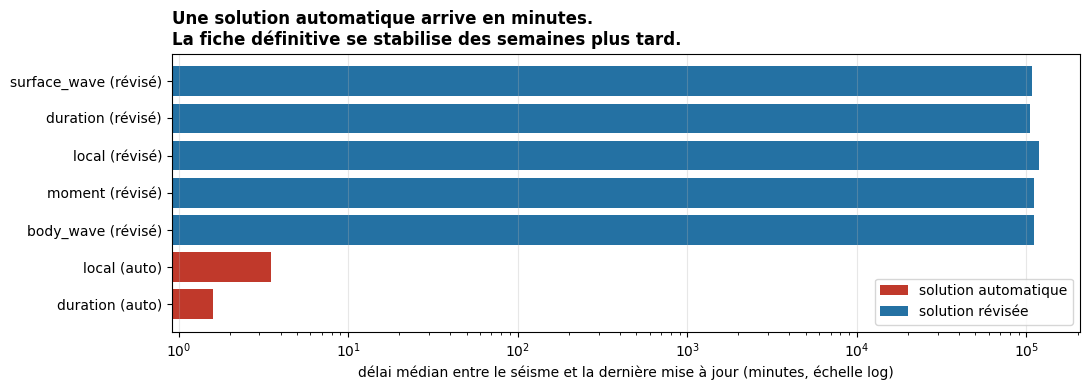

In [4]:
publication = lag.copy()
publication["lag_median_hours"] = (publication["lag_median_minutes"] / 60).round(1)
publication["lag_median_days"] = (publication["lag_median_minutes"] / 1440).round(1)

display(publication[["review_status", "magnitude_family", "events",
                     "lag_median_minutes", "lag_median_hours", "lag_median_days"]])

automatic = publication[publication.review_status == "automatic"]
reviewed = publication[publication.review_status == "reviewed"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(automatic.magnitude_family + " (auto)", automatic.lag_median_minutes,
        color="#c0392b", label="solution automatique")
ax.barh(reviewed.magnitude_family + " (révisé)", reviewed.lag_median_minutes,
        color="#2471a3", label="solution révisée")
ax.set_xscale("log")
ax.set_xlabel("délai médian entre le séisme et la dernière mise à jour (minutes, échelle log)")
ax.set_title("Une solution automatique arrive en minutes.\n"
             "La fiche définitive se stabilise des semaines plus tard.",
             fontweight="bold", loc="left")
ax.legend()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

> **Lecture.** L'échelle est logarithmique, sinon les barres automatiques
> seraient invisibles. Le rapport entre les deux régimes se compte en dizaines
> de milliers.
>
> **Précaution.** Le champ `updated` marque la dernière modification de la
> fiche, quelle qu'en soit la raison — révision de magnitude, mais aussi ajout
> d'un ShakeMap ou de signalements citoyens. Ce délai est donc une borne
> supérieure du temps de révision, pas le temps de révision lui-même.

---
## 2. Les réseaux sont-ils d'accord ? La question mal posée, et la bonne

Le brief de départ supposait que plusieurs réseaux déclarent le même séisme
séparément, et qu'il fallait les déduplider. **Vérification faite, c'est faux** :
sur 252 événements du flux, aucun alias n'apparaît comme événement distinct.
L'USGS fusionne déjà côté serveur.

Le vrai désaccord est ailleurs, et il est plus intéressant : **l'identité de
l'événement change dans le temps**. La solution automatique porte un identifiant
`usauto…`, la solution révisée un identifiant `us…`. Même séisme, deux noms.

In [5]:
traced = identity[identity.automatic_origin]
changed = identity[identity.identity_changed]

print(f"séismes au catalogue                         : {len(identity):>6}")
print(f"portant la trace d'une solution automatique  : {len(traced):>6} "
      f"({len(traced)/len(identity):.1%})")
print(f"dont l'identifiant retenu a changé depuis    : {len(changed):>6}")
print()
print("Chacun de ces séismes aurait été compté DEUX FOIS par une jointure sur")
print("`id` : une fois comme alerte automatique disparue, une fois comme")
print("événement révisé surgi de nulle part.")
print()

display(traced[["event_key", "usgs_id", "all_ids", "networks", "magnitude",
                "magnitude_type", "place"]].head(8))

séismes au catalogue                         :  17536
portant la trace d'une solution automatique  :   1151 (6.6%)
dont l'identifiant retenu a changé depuis    :   1151

Chacun de ces séismes aurait été compté DEUX FOIS par une jointure sur
`id` : une fois comme alerte automatique disparue, une fois comme
événement révisé surgi de nulle part.



,event_key,usgs_id,all_ids,networks,magnitude,magnitude_type,place
0,at00svnbao,us7000pwpu,"[at00svnbao, at00svnbaq, pt25122002, us7000pwp...","[at, usauto, us, pt, at, usauto]",6.40,mww,"289 km SSE of Ushuaia, Argentina"
1,at00supwy4,ci40925991,"[at00supwy4, ci40925991, ew1744650510, pt25104...","[ew, ci, us, at, usauto, pt]",5.21,mw,"5 km S of Julian, CA"
2,ak02598saaqj,us7000qe51,"[ak02598saaqj, at00szpyen, pt25201004, us7000q...","[at, us, usauto, pt, ak]",6.20,mww,"91 km SSE of Sand Point, Alaska"
3,ak025bb6gdes,us7000qtm0,"[ak025bb6gdes, at00t2168g, pt25246000, us7000q...","[at, ak, us, usauto, pt]",5.90,mww,"92 km SSW of Nikolski, Alaska"
4,ak025dxe5mlz,ak025dxe5mlz,"[ak025dxe5mlz, at00t4ygrd, pt25303000, us6000r...","[ak, at, usauto, pt, us]",5.40,ml,"48 km ESE of Fox River, Alaska"
5,ak0252mj9f2p,us6000pvm4,"[ak0252mj9f2p, at00ssat5y, pt25057001, us6000p...","[usauto, at, pt, us, ak]",5.80,mww,"153 km ESE of Ust’-Kamchatsk Staryy, Russia"
6,ak025925029r,us7000qd1y,"[ak025925029r, at00sziems, pt25197050, us7000q...","[at, us, pt, usauto, ak]",7.30,mww,"2025 Sand Point, Alaska Earthquake"
7,pr2025217000,pr2025217000,"[pr2025217000, pt25217001, us6000qy7q, usauto6...","[usauto, pr, us, usauto, pt]",5.70,ml,"38 km SE of Boca de Yuma, Dominican Republic"


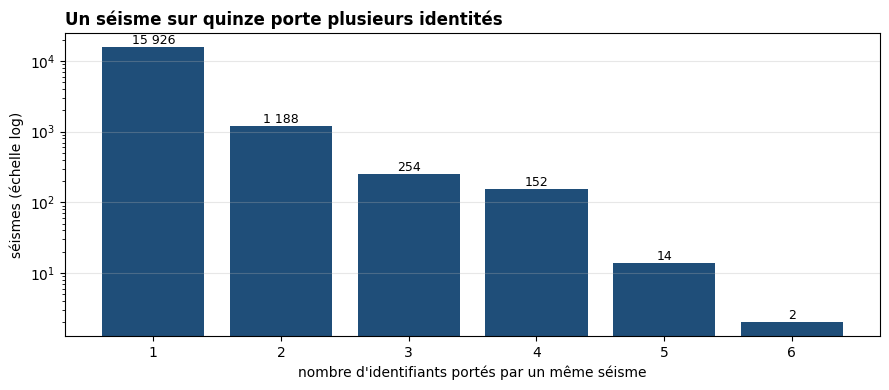

In [6]:
distribution = identity.identifier_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(distribution.index.astype(str), distribution.values, color="#1f4e79")
for x, y in zip(range(len(distribution)), distribution.values):
    ax.text(x, y, f"{y:,}".replace(",", " "), ha="center", va="bottom", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("nombre d'identifiants portés par un même séisme")
ax.set_ylabel("séismes (échelle log)")
ax.set_title("Un séisme sur quinze porte plusieurs identités",
             fontweight="bold", loc="left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

---
## 3. À quel seuil d'alerte, quel taux de fausse alerte ?

C'est la question opérationnelle : un service de protection civile doit choisir
un seuil de magnitude automatique au-delà duquel il déclenche.

La table `alert_reliability` croise chaque seuil candidat avec les séismes dont
nous connaissons **à la fois** la magnitude automatique et la magnitude finale.

In [7]:
if reliability.events_evaluated.max() >= 30:
    display(reliability)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(reliability.threshold, reliability.false_alert_rate * 100,
            marker="o", color="#c0392b", label="fausses alertes")
    ax.plot(reliability.threshold, reliability.miss_rate * 100,
            marker="s", color="#2471a3", label="séismes manqués")
    ax.set_xlabel("seuil de magnitude automatique")
    ax.set_ylabel("taux (%)")
    ax.set_title("Le compromis du seuil d'alerte", fontweight="bold", loc="left")
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
else:
    n = int(reliability.events_evaluated.max()) if len(reliability) else 0
    print(f"Échantillon insuffisant : {n} séisme(s) avec une magnitude")
    print("automatique ET une magnitude finale connues.")
    print()
    print("Cette table se construit à mesure que le flux tourne. Elle est")
    print("volontairement laissée visible plutôt que masquée : un taux de fausse")
    print("alerte calculé sur deux événements ne serait pas un résultat, ce")
    print("serait une illusion de résultat.")
    display(reliability)

Échantillon insuffisant : 2 séisme(s) avec une magnitude
automatique ET une magnitude finale connues.

Cette table se construit à mesure que le flux tourne. Elle est
volontairement laissée visible plutôt que masquée : un taux de fausse
alerte calculé sur deux événements ne serait pas un résultat, ce
serait une illusion de résultat.


,threshold,events_evaluated,alerts_raised,alerts_confirmed,false_alerts,missed_events,false_alert_rate,miss_rate
0,3.0,2,0,0,0,0,NaN,0.0
1,3.5,2,0,0,0,0,NaN,0.0
2,4.0,2,0,0,0,0,NaN,0.0
3,4.5,2,0,0,0,0,NaN,0.0
4,5.0,2,0,0,0,0,NaN,0.0
5,5.5,2,0,0,0,0,NaN,0.0
6,6.0,2,0,0,0,0,NaN,0.0
7,6.5,2,0,0,0,0,NaN,0.0
8,7.0,2,0,0,0,0,NaN,0.0


---
## 4. Six échelles de magnitude qui ne mesurent pas la même chose

C'est le piège le plus discret du jeu de données. Une M4,9 `ml` et une M4,9
`mww` ne décrivent pas le même phénomène physique.

**Nous ne convertissons pas.** Les formules entre échelles sont régionales et
empiriques : une relation calibrée en Californie ne vaut pas en Indonésie.
Appliquer une formule universelle produirait des nombres d'apparence rigoureuse
et sans fondement.

La couche Silver qualifie donc chaque mesure — famille, seuil de saturation —
au lieu de la transformer.

,magnitude_family,magnitude_type,events,magnitude_avg,magnitude_min,magnitude_max,saturation_threshold,saturated
0,body_wave,mb,15614,4.444,4.00,6.30,6.5,0
1,moment,mww,1437,5.309,4.40,8.80,10.0,0
2,moment,mwr,347,4.374,4.00,5.20,10.0,0
3,local,ml,74,4.169,0.59,5.85,6.5,0
4,duration,md,30,3.677,0.78,4.55,5.0,0
5,moment,mw,27,4.357,4.00,5.70,10.0,0
6,moment,mwb,6,5.783,5.20,6.10,10.0,0
7,surface_wave,ms_vx,1,4.900,4.90,4.90,8.0,0


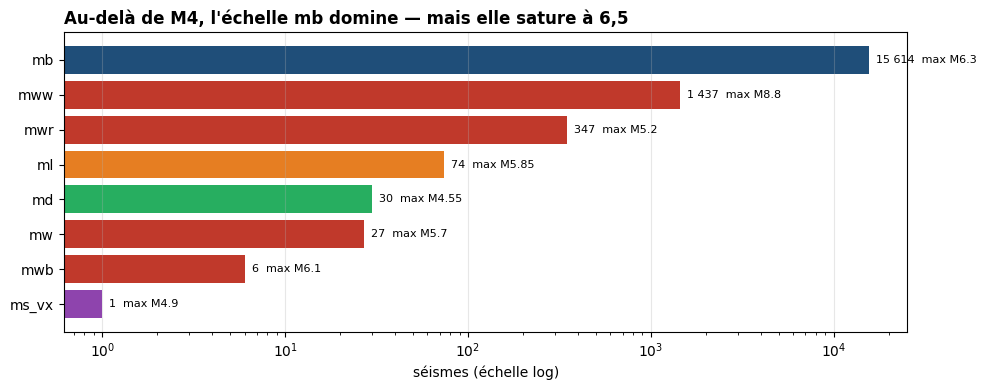

In [8]:
display(scales)

fig, ax = plt.subplots(figsize=(10, 4))
ordered = scales.sort_values("events", ascending=True)
colours = {"body_wave": "#1f4e79", "moment": "#c0392b", "local": "#e67e22",
           "duration": "#27ae60", "surface_wave": "#8e44ad"}
ax.barh(ordered.magnitude_type, ordered.events,
        color=[colours.get(f, "#888") for f in ordered.magnitude_family])
for y, (n, mx) in enumerate(zip(ordered.events, ordered.magnitude_max)):
    ax.text(n, y, f"  {n:,}".replace(",", " ") + f"  max M{mx}", va="center", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("séismes (échelle log)")
ax.set_title("Au-delà de M4, l'échelle mb domine — mais elle sature à 6,5",
             fontweight="bold", loc="left")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

> **Lecture.** `mb` couvre 89 % des séismes M≥4 mais **sature vers 6,5** : au
> delà, elle sous-estime systématiquement. `mww`, qui ne sature pas, ne
> représente que 10 % des mesures — mais c'est elle qui porte les magnitudes
> extrêmes du jeu, jusqu'à M8,8.
>
> Classer les séismes par `mag` sans tenir compte de `magType` reviendrait donc
> à faire remonter des `mb` moyennes au-dessus de `mww` majeures.
>
> Sur ce jeu limité à 2025, aucune magnitude n'atteint son seuil de saturation :
> le garde-fou est en place mais n'a rien à signaler. Il servira dès qu'un
> millésime contiendra un séisme majeur.

---
## Ce que ces données permettent, et ce qu'elles ne permettent pas

**Établi, sur 17 536 séismes :**

- une solution automatique est publiée en quelques minutes ; la fiche définitive
  se stabilise des semaines plus tard ;
- 6,6 % des séismes portent la trace d'une solution automatique remplacée, et
  **tous** ont vu leur identifiant changer — une jointure naïve les compterait
  deux fois ;
- l'échelle de magnitude dominante au-delà de M4 sature avant les magnitudes
  qui comptent le plus.

**Pas encore établi :** le seuil d'alerte optimal. Il exige d'observer le même
séisme en version automatique **puis** en version révisée, ce que seul le flux
accumulé permet. La table existe, sa méthode est écrite, son échantillon grandit
à chaque heure d'écoute.

C'est une limite du temps d'observation, pas de l'architecture — et la dire vaut
mieux que de publier un taux calculé sur deux événements.